In [1]:
# Paste this entire cell into Jupyter and run it to generate complaints_dataset_10000.csv
import random, csv, os
from itertools import chain

random.seed(42)
OUTPUT = "complaints_dataset_10000.csv"
NUM_PER_CATEGORY = 1000  # 1000 * 10 categories = 10,000 rows

categories_templates = {
    "Roads": [
        "Potholes on the main road causing accidents",
        "Street is damaged and difficult for vehicles",
        "Debris blocking the road and not cleared",
        "Divider damaged and unsafe for traffic",
        "Footpath broken and dangerous for pedestrians"
    ],
    "Sanitation": [
        "Garbage not collected for many days",
        "Open drains causing mosquito problem",
        "Public toilet is dirty and unusable",
        "Waste dumped in open area creating strong smell",
        "Sewage water overflowing on the street"
    ],
    "Electricity": [
        "Frequent power cuts disturbing daily life",
        "Street lights not working at night",
        "Transformer making unusual noise and sparking",
        "Voltage fluctuations damaging appliances",
        "Electric pole leaning dangerously and may fall"
    ],
    "Water": [
        "No drinking water supply since yesterday",
        "Pipeline leakage flooding the street",
        "Tap water is muddy and smells bad",
        "Irregular water supply causing problems",
        "Overhead water tank leaking heavily"
    ],
    "Health": [
        "Health center closed during working hours",
        "Medicines not available in government hospital pharmacy",
        "Stray dogs attacking people, need control measures",
        "Ambulance not arriving quickly during emergencies",
        "Hospital toilets unhygienic and unusable"
    ],
    "Education": [
        "School needs more benches and fans",
        "Teachers absent regularly and classes not held",
        "Mid-day meal quality is poor and insufficient",
        "School building walls are cracked and unsafe",
        "No proper drinking water facility in school"
    ],
    "PublicSafety": [
        "Chain snatching incidents reported in the area",
        "Drunken driving at night causing danger",
        "Illegal sand mining observed nearby",
        "Loudspeakers used at night disturbing sleep",
        "Speeding vehicles in residential area need control"
    ],
    "Agriculture": [
        "Paddy crops affected by pest attack, need support",
        "Fertilizer subsidy not credited to farmers",
        "Irrigation water not reaching the fields",
        "Crop insurance claim pending for a long time",
        "Seeds not available on time for farmers"
    ],
    "Transport": [
        "City bus route cancelled suddenly without notice",
        "Auto drivers overcharging passengers on routes",
        "Railway crossing gate not working causing traffic jams",
        "Bus stop lacks shelter and seating for passengers",
        "Traffic signals not working properly at busy junctions"
    ],
    "Other": [
        "Need new ration card application processed quickly",
        "Aadhaar update facility not available at office",
        "Noise pollution from nearby factory at night",
        "Delay in pension disbursement for senior citizens",
        "Government office staff rude and not helpful"
    ]
}

intensities = ["severe", "serious", "major", "minor", "urgent", "frequent", "repeated"]
time_phrases = ["since last week", "for many days", "since yesterday", "today", "for a month", "regularly", "for the past few days"]
prefixes = ["", "Attention:", "Complaint:", "Kindly note:"]
slang_suffixes = ["plz solve asap", "kindly fix this", "no one is taking action", "please take action", "this is urgent", "requesting help", "cheppandi emi chestaru", "kripya isko thik karein", "please resolve asap"]
synonym_map = {"not": ["not", "no", "never"], "broken": ["broken", "damaged", "cracked"], "leaking": ["leaking", "dripping", "seeping"], "dirty": ["dirty", "unclean", "filthy"], "urgent": ["urgent", "immediate", "asap"], "problem": ["problem", "issue", "concern"]}
typo_map = {"water": ["watr", "waater", "wter"], "garbage": ["garbeg", "garbge"], "street": ["stret", "strt"], "school": ["schol", "schoool"], "ambulance": ["ambulnce", "ambulence"], "toilet": ["toilett", "toilt"], "electric": ["eletric", "elecetric"], "pipeline": ["pipelin", "pipline"], "signal": ["signl", "sigal"]}

def maybe_replace_synonym(text):
    for k, vals in synonym_map.items():
        if f" {k} " in f" {text} " and random.random() < 0.25:
            text = text.replace(k, random.choice(vals), 1)
    return text

def maybe_inject_typos(text):
    words = text.split()
    new_words = []
    for w in words:
        lw = w.lower().strip(",-.")
        if lw in typo_map and random.random() < 0.08:
            new_words.append(random.choice(typo_map[lw]))
        else:
            new_words.append(w)
    return " ".join(new_words)

def maybe_add_codemix(text):
    if random.random() < 0.18:
        return text + " - " + random.choice(["cheppandi", "kripya", "plz", "please resolve", "please fix"])
    return text

def generate_one(template):
    text = template
    if random.random() < 0.18:
        text = random.choice(prefixes) + " " + text
    if random.random() < 0.9:
        text = f"{text} - {random.choice(intensities)} issue {random.choice(time_phrases)}"
    if random.random() < 0.3:
        text = text + " - " + random.choice(slang_suffixes)
    if random.random() < 0.35:
        text = maybe_replace_synonym(text)
    if random.random() < 0.16:
        text = maybe_inject_typos(text)
    if random.random() < 0.18:
        text = maybe_add_codemix(text)
    return text

rows = []
for category, templates in categories_templates.items():
    per_template = max(1, NUM_PER_CATEGORY // len(templates))
    for tpl in templates:
        for _ in range(per_template):
            rows.append((generate_one(tpl), category))

random.shuffle(rows)

# Ensure correct total rows
total_expected = NUM_PER_CATEGORY * len(categories_templates)
if len(rows) < total_expected:
    extra_needed = total_expected - len(rows)
    all_templates = [t for tpls in categories_templates.values() for t in tpls]
    for _ in range(extra_needed):
        tpl = random.choice(all_templates)
        cat = next(cat for cat, tpls in categories_templates.items() if tpl in tpls)
        rows.append((generate_one(tpl), cat))

with open(OUTPUT, "w", newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["complaint_text", "sector"])
    writer.writerows(rows)

print(f"Generated {len(rows)} rows and wrote to {OUTPUT}")


Generated 10000 rows and wrote to complaints_dataset_10000.csv


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# Load Dataset 

In [3]:
# Load dataset
df = pd.read_csv("complaints_dataset_10000.csv")

# Display first few rows
df.head()


,complaint_text,sector
0,Transformer making unusual noise and sparking ...,Electricity
1,No proper drinking water facility in school - ...,Education
2,Fertilizer subsidy not credited to farmers - f...,Agriculture
3,City bus route cancelled suddenly without noti...,Transport
4,Complaint: Teachers absent regularly and class...,Education


# Explore Dataset

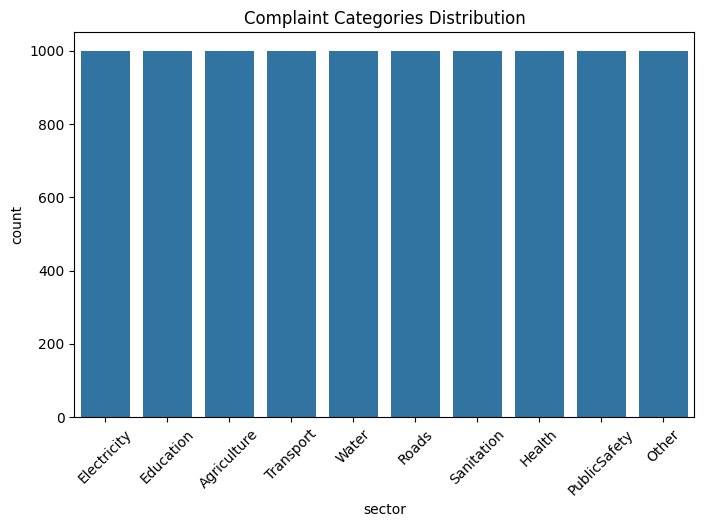

In [4]:
# Check class distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sector')
plt.xticks(rotation=45)
plt.title("Complaint Categories Distribution")
plt.show()


# Encode Labels

In [5]:
# Encode target labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['sector'])

# Save mapping for backend use
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'Agriculture': 0, 'Education': 1, 'Electricity': 2, 'Health': 3, 'Other': 4, 'PublicSafety': 5, 'Roads': 6, 'Sanitation': 7, 'Transport': 8, 'Water': 9}


# Text Preprocessing

In [6]:
# Split dataset
X = df['complaint_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tokenization
max_words = 5000   # maximum unique words
max_len = 50       # max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


# Preparing Labels

In [7]:
# Convert labels to categorical (for multi-class classification)
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


# Build Model


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 1.0


# Plot Training Results

📄 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       200
           3       1.00      1.00      1.00       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       1.00      1.00      1.00       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       1.00      1.00      1.00       200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



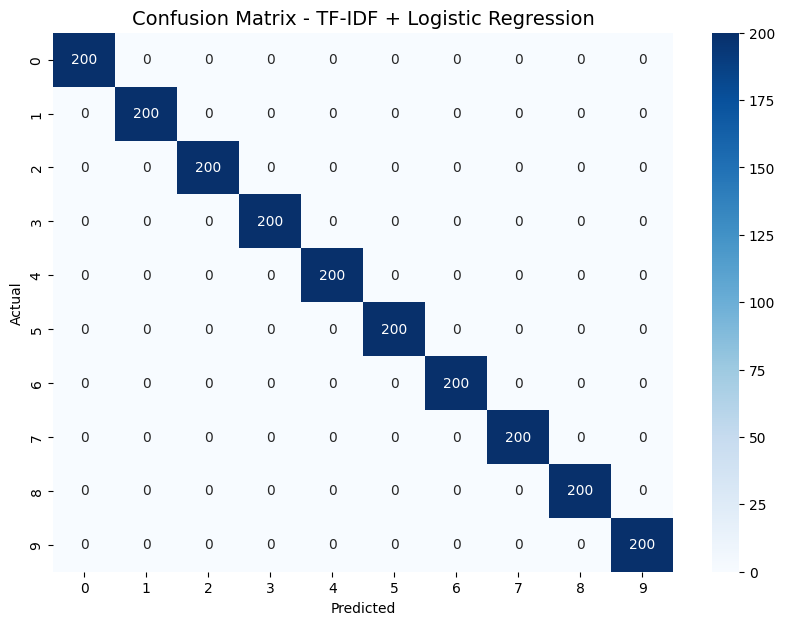

C:\Users\Gowtham Ravuri\AppData\Local\Temp\ipykernel_4588\4155924569.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, order=clf.classes_, palette="Set2")


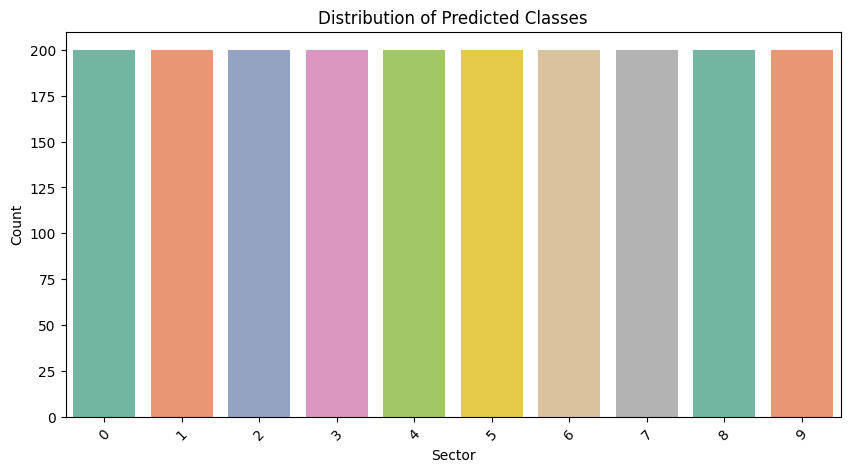

In [9]:
# 📊 Evaluation & Plotting Results for TF-IDF Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Detailed classification report
print("📄 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.title("Confusion Matrix - TF-IDF + Logistic Regression", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Bar chart of class distribution in predictions
plt.figure(figsize=(10,5))
sns.countplot(x=y_pred, order=clf.classes_, palette="Set2")
plt.title("Distribution of Predicted Classes")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Saving Model

In [10]:
import joblib

# Save trained model and vectorizer
joblib.dump(clf, "complaint_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


# Testing Prediction

In [11]:
import joblib

# Load model, vectorizer, and encoder
clf = joblib.load("complaint_classifier.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
encoder = joblib.load("label_encoder.pkl")

# Predict function
def predict_complaint(text):
    X = vectorizer.transform([text])
    pred_id = clf.predict(X)[0]       # numeric label
    pred_label = encoder.inverse_transform([pred_id])[0]  # convert back
    return pred_label

# Example
print(predict_complaint("Street lights not working for the past 3 days"))


Electricity
